In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [2]:
df=pd.read_csv("C:/Users/ASUS/Downloads/food_wastage_data.csv")
df

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25
...,...,...,...,...,...,...,...,...,...,...,...
1777,Baked Goods,310,Corporate,350,Room Temperature,Regular,Summer,Finger Food,Urban,High,35
1778,Baked Goods,284,Social Gathering,443,Room Temperature,Regular,Winter,Buffet,Rural,Low,32
1779,Fruits,220,Wedding,300,Room Temperature,Regular,All Seasons,Finger Food,Urban,Moderate,15
1780,Fruits,250,Wedding,350,Room Temperature,Regular,All Seasons,Finger Food,Rural,Moderate,20


In [3]:
df.head()

,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Type of Food           1782 non-null   object
 1   Number of Guests       1782 non-null   int64 
 2   Event Type             1782 non-null   object
 3   Quantity of Food       1782 non-null   int64 
 4   Storage Conditions     1782 non-null   object
 5   Purchase History       1782 non-null   object
 6   Seasonality            1782 non-null   object
 7   Preparation Method     1782 non-null   object
 8   Geographical Location  1782 non-null   object
 9   Pricing                1782 non-null   object
 10  Wastage Food Amount    1782 non-null   int64 
dtypes: int64(3), object(8)
memory usage: 153.3+ KB


In [5]:
df.describe()

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.000000,1782.000000,1782.000000
mean,317.804714,411.125701,28.536476
std,67.829658,65.204674,10.461317
min,207.000000,280.000000,10.000000
25%,267.000000,350.000000,20.000000
50%,302.000000,400.000000,26.500000
75%,350.000000,480.000000,35.000000
max,491.000000,500.000000,63.000000


In [6]:
df.isnull().sum()

Type of Food             0
Number of Guests         0
Event Type               0
Quantity of Food         0
Storage Conditions       0
Purchase History         0
Seasonality              0
Preparation Method       0
Geographical Location    0
Pricing                  0
Wastage Food Amount      0
dtype: int64

In [7]:
# Get all numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Columns:")
print(numerical_columns)


Numerical Columns:
Index(['Number of Guests', 'Quantity of Food', 'Wastage Food Amount'], dtype='object')


In [8]:
# Get all categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:")
print(categorical_columns)


Categorical Columns:
Index(['Type of Food', 'Event Type', 'Storage Conditions', 'Purchase History',
       'Seasonality', 'Preparation Method', 'Geographical Location',
       'Pricing'],
      dtype='object')


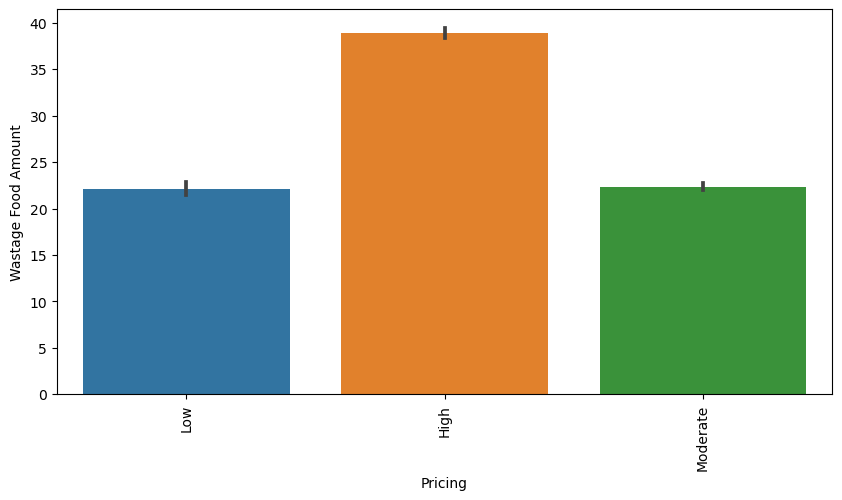

In [10]:
#bar chart to show relationship between price and Wastage Food Amount
plt.figure(figsize=(10,5))
sns.barplot(x='Pricing',y='Wastage Food Amount',data=df)
plt.xticks(rotation=90)
plt.show()

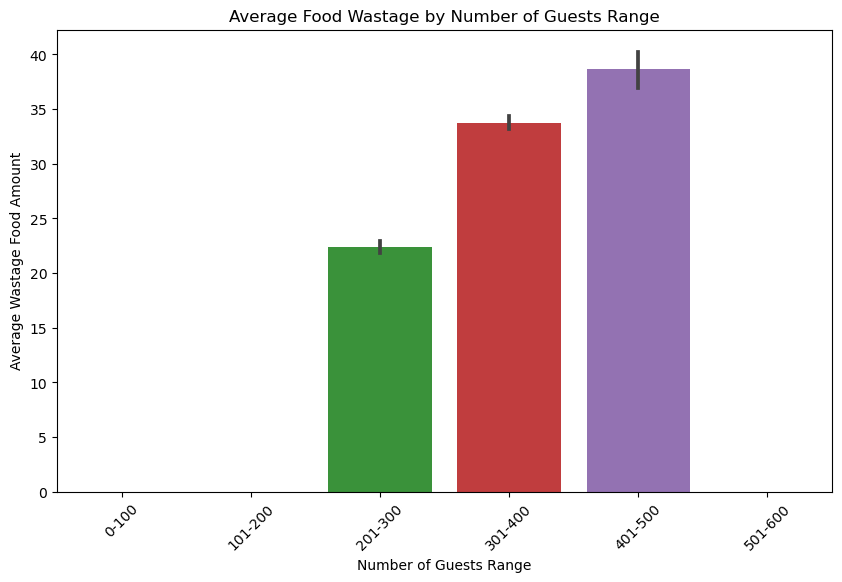

In [11]:
# Bin the Number of Guests into ranges
bins = [0, 100, 200, 300, 400, 500, 600]
labels = ['0-100', '101-200', '201-300', '301-400', '401-500', '501-600']
df['Number of Guests Range'] = pd.cut(df['Number of Guests'], bins=bins, labels=labels)

# Create a bar plot for Number of Guests Range vs. Food Wastage
plt.figure(figsize=(10, 6))
sns.barplot(x='Number of Guests Range', y='Wastage Food Amount', data=df)
plt.title('Average Food Wastage by Number of Guests Range')
plt.xlabel('Number of Guests Range')
plt.ylabel('Average Wastage Food Amount')
plt.xticks(rotation=45)
plt.show()



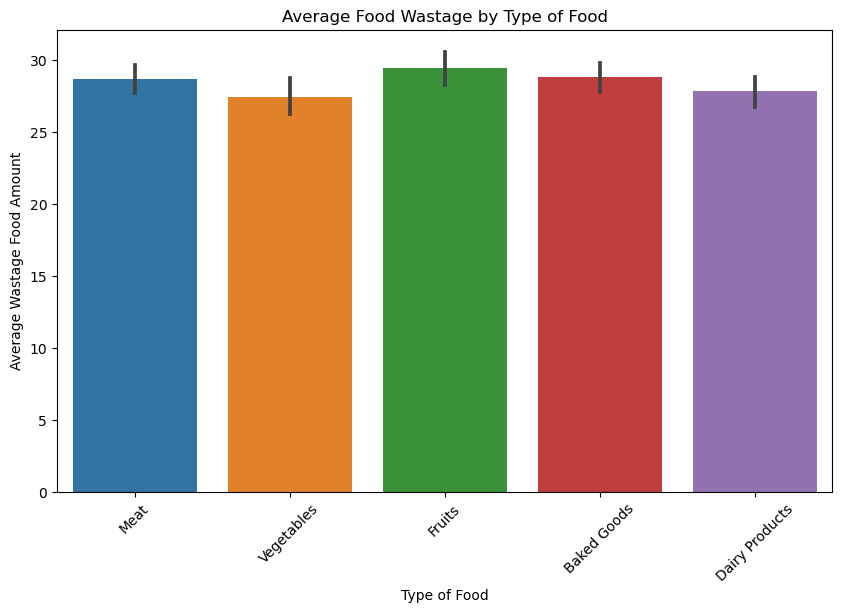

In [12]:
# bar plot for Type of Food
plt.figure(figsize=(10, 6))
sns.barplot(x='Type of Food', y='Wastage Food Amount', data=df)
plt.xticks(rotation=45)
plt.title('Average Food Wastage by Type of Food')
plt.xlabel('Type of Food')
plt.ylabel('Average Wastage Food Amount')
plt.show()


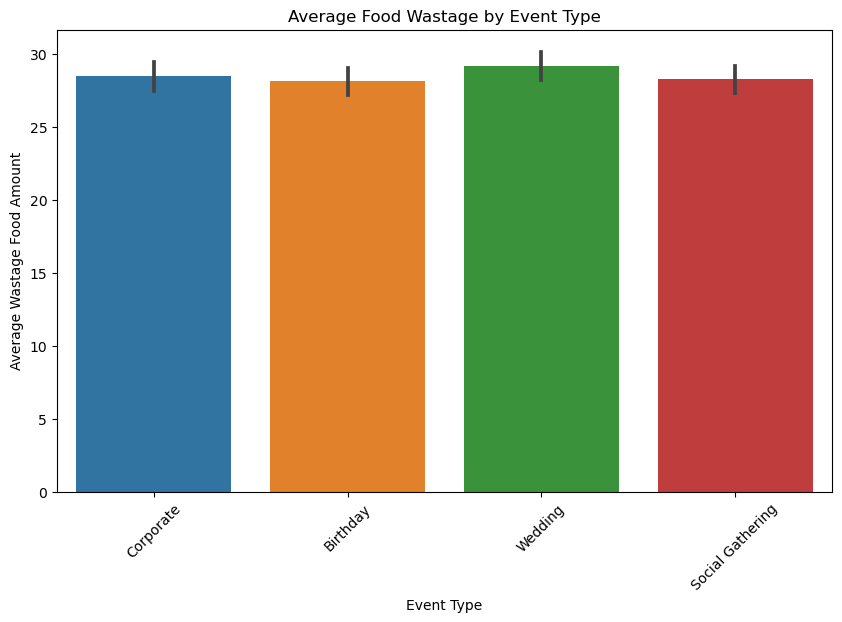

In [13]:
# Create a bar plot for Event Type vs. Average Food Wastage
plt.figure(figsize=(10, 6))
sns.barplot(x='Event Type', y='Wastage Food Amount', data=df)
plt.title('Average Food Wastage by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Average Wastage Food Amount')
plt.xticks(rotation=45)
plt.show()


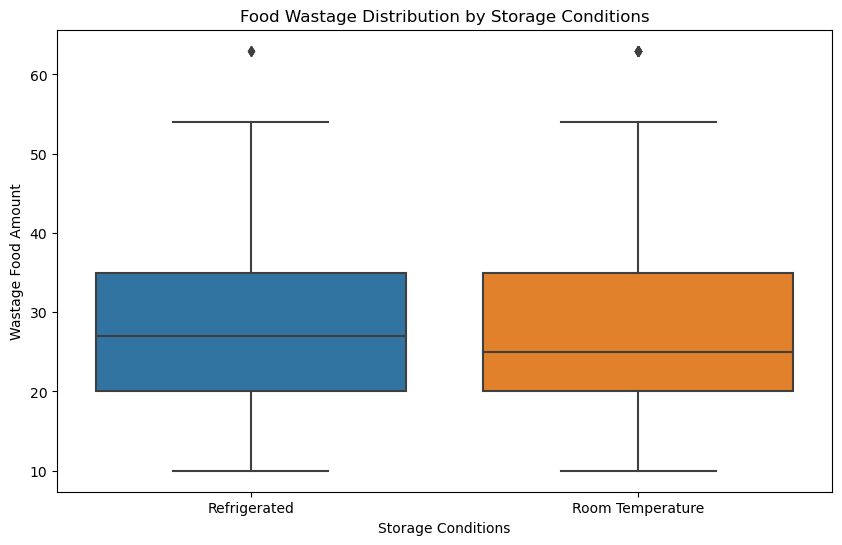

In [14]:

# Create a box plot for Storage Conditions vs. Food Wastage
plt.figure(figsize=(10, 6))
sns.boxplot(x='Storage Conditions', y='Wastage Food Amount', data=df)
plt.title('Food Wastage Distribution by Storage Conditions')
plt.xlabel('Storage Conditions')
plt.ylabel('Wastage Food Amount')
plt.show()


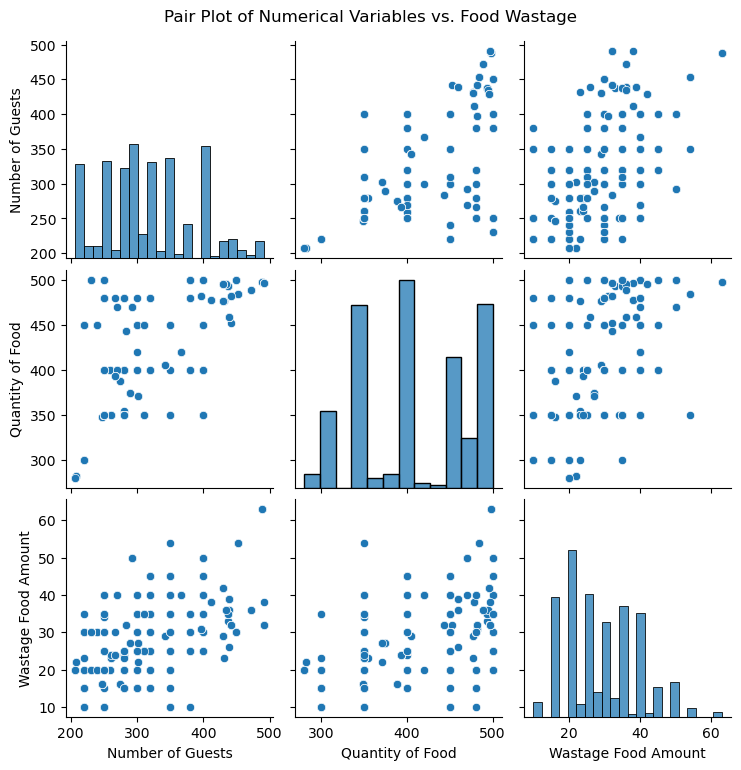

In [15]:
# Select relevant numerical columns
numerical_columns = ['Number of Guests', 'Quantity of Food']

# Add more numerical columns to the list as needed

# Add 'Wastage Food Amount' to the columns for visualization
numerical_columns.append('Wastage Food Amount')

# Create the pair plot
sns.pairplot(df[numerical_columns])
plt.suptitle('Pair Plot of Numerical Variables vs. Food Wastage', y=1.02)
plt.show()


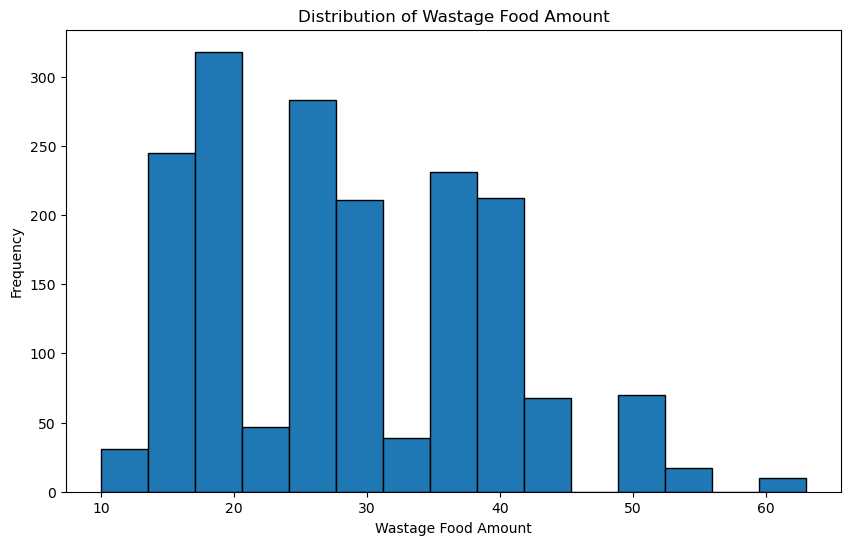

In [16]:
# Create a histogram of Wastage Food Amount
plt.figure(figsize=(10, 6))
plt.hist(df['Wastage Food Amount'], bins=15, edgecolor='black')
plt.title('Distribution of Wastage Food Amount')
plt.xlabel('Wastage Food Amount')
plt.ylabel('Frequency')
plt.show()


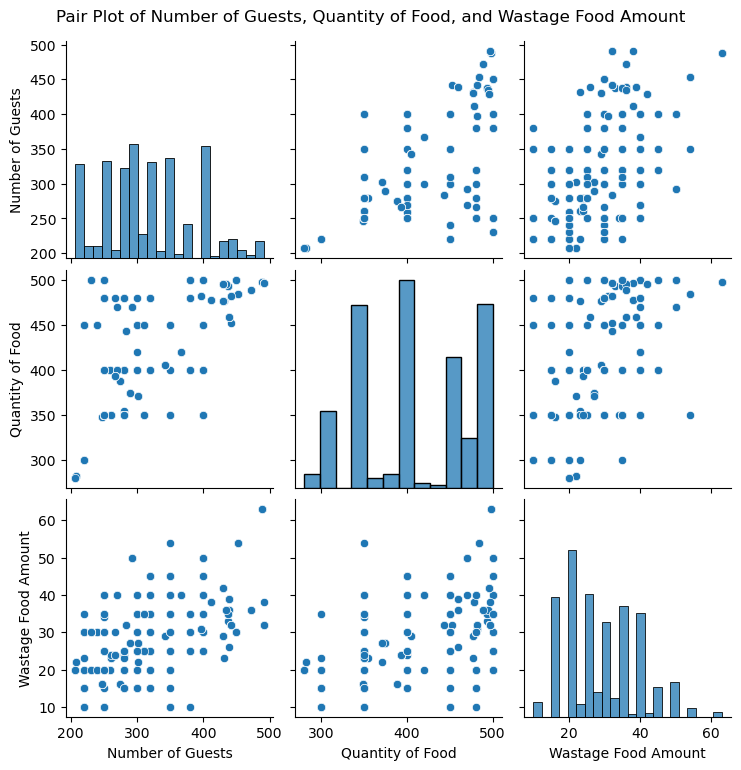

In [17]:
# Select relevant numerical columns
numerical_columns = ['Number of Guests', 'Quantity of Food', 'Wastage Food Amount']

# Create the pair plot
sns.pairplot(df[numerical_columns])
plt.suptitle('Pair Plot of Number of Guests, Quantity of Food, and Wastage Food Amount', y=1.02)
plt.show()


In [18]:
df_encoded = pd.get_dummies(df, drop_first=False)  # drop_first=False keeps all columns

In [20]:
categorical_columns = ['Type of Food', 'Event Type', 'Storage Conditions', 'Purchase History',
                       'Seasonality', 'Preparation Method', 'Geographical Location', 'Pricing']

# Perform one-hot encoding on the categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=False)

# Show the encoded DataFrame
print(df_encoded.head())

   Number of Guests  Quantity of Food  Wastage Food Amount  \
0               310               450                   25   
1               400               500                   40   
2               302               371                   27   
3               491               497                   32   
4               300               400                   25   

  Number of Guests Range  Type of Food_Baked Goods  \
0                301-400                         0   
1                301-400                         0   
2                301-400                         0   
3                401-500                         0   
4                201-300                         0   

   Type of Food_Dairy Products  Type of Food_Fruits  Type of Food_Meat  \
0                            0                    0                  1   
1                            0                    0                  1   
2                            0                    0                  0   
3     

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2720\3980115988.py:5: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


Correlation Matrix:
                     Number of Guests  Quantity of Food  Wastage Food Amount
Number of Guests             1.000000          0.794401             0.650421
Quantity of Food             0.794401          1.000000             0.638648
Wastage Food Amount          0.650421          0.638648             1.000000


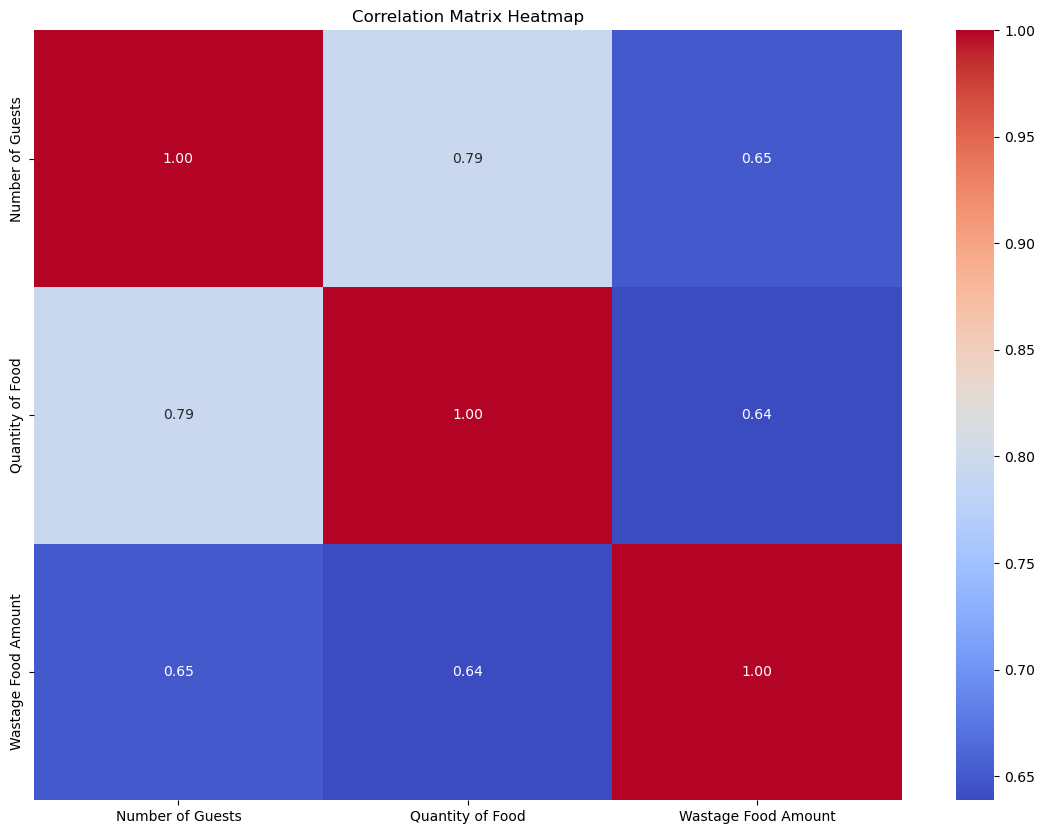

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_2720\3065032378.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_encoded.corr()


Correlation Matrix:
                                     Number of Guests  Quantity of Food  \
Number of Guests                             1.000000          0.794401   
Quantity of Food                             0.794401          1.000000   
Wastage Food Amount                          0.650421          0.638648   
Type of Food_Baked Goods                     0.027180          0.014805   
Type of Food_Dairy Products                 -0.025518         -0.039056   
Type of Food_Fruits                          0.030943          0.027762   
Type of Food_Meat                           -0.001936          0.024453   
Type of Food_Vegetables                     -0.037647         -0.035452   
Event Type_Birthday                          0.032707         -0.004301   
Event Type_Corporate                        -0.022645         -0.004648   
Event Type_Social Gathering                 -0.034600         -0.038155   
Event Type_Wedding                           0.028284          0.047745   
Stora

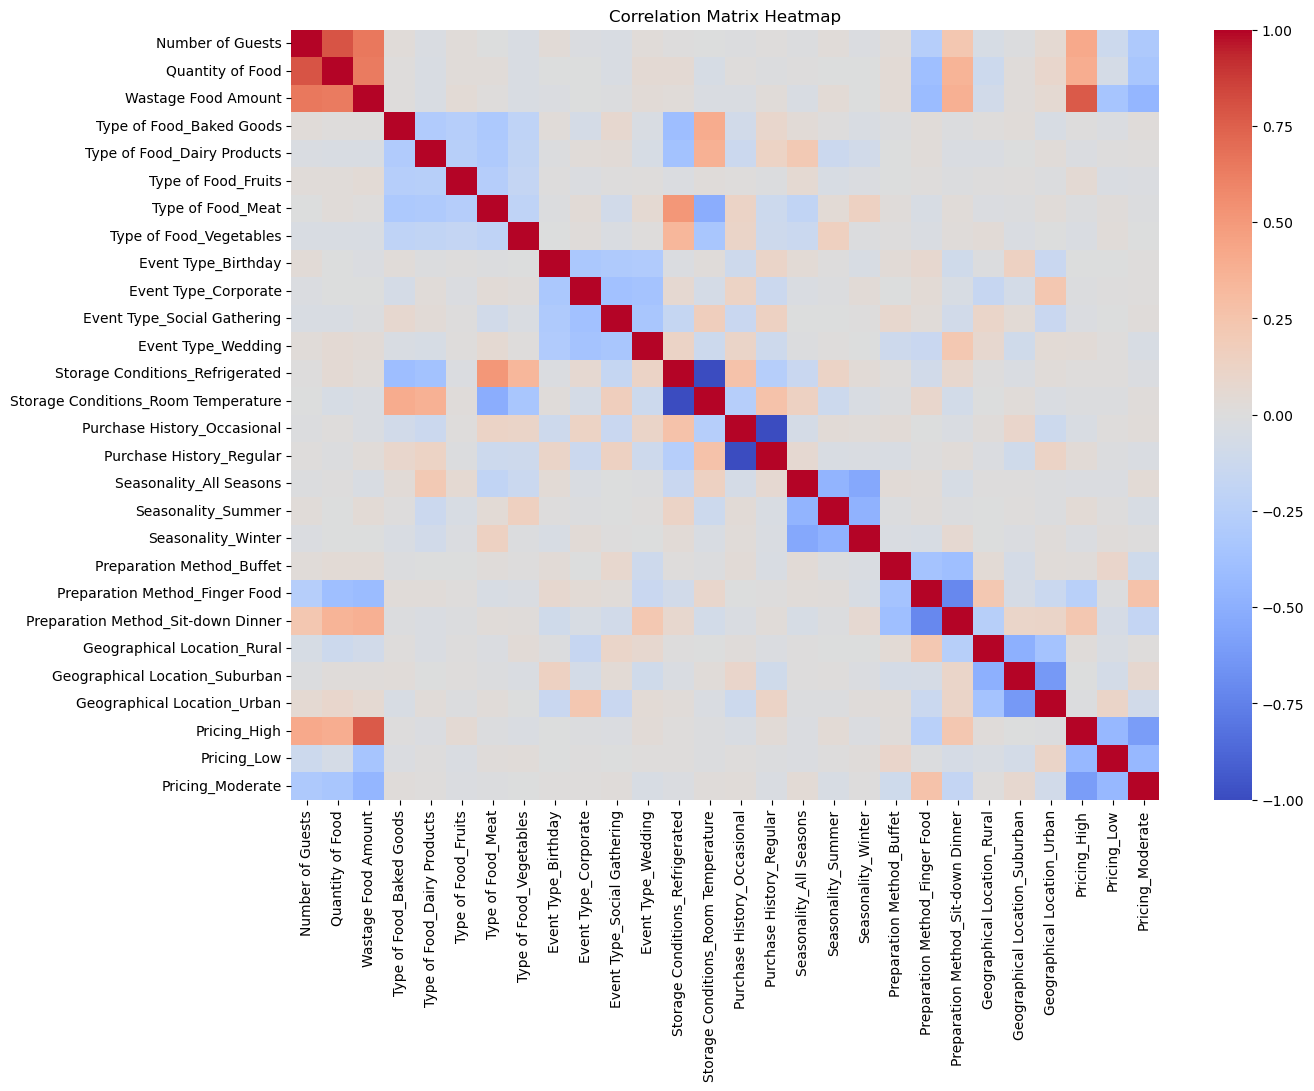

In [26]:
correlation_matrix = df_encoded.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(correlation_matrix)

# Visualize the correlation matrix as a heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", cbar=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [28]:
correlation_matrix = df_encoded.corr()

# Convert correlation matrix to a tidy table (melted format)
correlation_table = correlation_matrix.unstack().reset_index()
correlation_table.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Remove self-correlations (correlation = 1.0 for same features)
correlation_table = correlation_table[correlation_table['Feature 1'] != correlation_table['Feature 2']]

# Sort by absolute correlation values for better insights
correlation_table = correlation_table.sort_values(by='Correlation', key=abs, ascending=False)

# Display the top correlations
print("Correlation Table (Top Correlations):")
print(correlation_table.head(20))

Correlation Table (Top Correlations):
                               Feature 1                            Feature 2  \
349      Storage Conditions_Refrigerated  Storage Conditions_Room Temperature   
376  Storage Conditions_Room Temperature      Storage Conditions_Refrigerated   
407          Purchase History_Occasional             Purchase History_Regular   
434             Purchase History_Regular          Purchase History_Occasional   
1                       Number of Guests                     Quantity of Food   
28                      Quantity of Food                     Number of Guests   
81                   Wastage Food Amount                         Pricing_High   
702                         Pricing_High                  Wastage Food Amount   
608   Preparation Method_Sit-down Dinner       Preparation Method_Finger Food   
581       Preparation Method_Finger Food   Preparation Method_Sit-down Dinner   
2                       Number of Guests                  Wastage Food 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_2720\2512329973.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_encoded.corr()


In [30]:
feature_pairs = correlation_table[['Feature 1', 'Feature 2']].values.flatten()
selected_features = list(set(feature_pairs))  # Remove duplicates

In [31]:
selected_features

['Type of Food_Meat',
 'Pricing_Low',
 'Event Type_Social Gathering',
 'Storage Conditions_Room Temperature',
 'Event Type_Wedding',
 'Preparation Method_Finger Food',
 'Number of Guests',
 'Event Type_Corporate',
 'Type of Food_Baked Goods',
 'Preparation Method_Sit-down Dinner',
 'Quantity of Food',
 'Storage Conditions_Refrigerated',
 'Preparation Method_Buffet',
 'Type of Food_Dairy Products',
 'Geographical Location_Suburban',
 'Seasonality_Summer',
 'Seasonality_Winter',
 'Event Type_Birthday',
 'Geographical Location_Rural',
 'Type of Food_Fruits',
 'Wastage Food Amount',
 'Pricing_Moderate',
 'Purchase History_Regular',
 'Purchase History_Occasional',
 'Seasonality_All Seasons',
 'Pricing_High',
 'Geographical Location_Urban',
 'Type of Food_Vegetables']

In [32]:
selected_features.append('Wastage Food Amount')  # Add the target column

In [34]:
training_data = df_encoded[selected_features]

In [35]:
training_data

,Type of Food_Meat,Pricing_Low,Event Type_Social Gathering,Storage Conditions_Room Temperature,Event Type_Wedding,Preparation Method_Finger Food,Number of Guests,Event Type_Corporate,Type of Food_Baked Goods,Preparation Method_Sit-down Dinner,...,Type of Food_Fruits,Wastage Food Amount,Pricing_Moderate,Purchase History_Regular,Purchase History_Occasional,Seasonality_All Seasons,Pricing_High,Geographical Location_Urban,Type of Food_Vegetables,Wastage Food Amount
0,1,1,0,0,0,0,310,1,0,0,...,0,25,0,1,0,1,0,1,0,25
1,1,0,0,1,0,0,400,0,0,0,...,0,40,0,1,0,0,1,0,0,40
2,0,1,0,0,0,0,302,0,0,0,...,0,27,0,1,0,0,0,0,1,27
3,1,0,0,0,0,1,491,0,0,0,...,0,32,0,1,0,1,1,0,0,32
4,1,0,0,0,0,1,300,1,0,0,...,0,25,1,1,0,0,0,1,0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,0,0,0,1,0,1,310,1,1,0,...,0,35,0,1,0,0,1,1,0,35
1778,0,1,1,1,0,0,284,0,1,0,...,0,32,0,1,0,0,0,0,0,32
1779,0,0,0,1,1,1,220,0,0,0,...,1,15,1,1,0,1,0,1,0,15
1780,0,0,0,1,1,1,250,0,0,0,...,1,20,1,1,0,1,0,0,0,20


In [36]:
X = training_data.drop('Wastage Food Amount', axis=1)  # Features
y = training_data['Wastage Food Amount']  # Target

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
X

,Type of Food_Meat,Pricing_Low,Event Type_Social Gathering,Storage Conditions_Room Temperature,Event Type_Wedding,Preparation Method_Finger Food,Number of Guests,Event Type_Corporate,Type of Food_Baked Goods,Preparation Method_Sit-down Dinner,...,Event Type_Birthday,Geographical Location_Rural,Type of Food_Fruits,Pricing_Moderate,Purchase History_Regular,Purchase History_Occasional,Seasonality_All Seasons,Pricing_High,Geographical Location_Urban,Type of Food_Vegetables
0,1,1,0,0,0,0,310,1,0,0,...,0,0,0,0,1,0,1,0,1,0
1,1,0,0,1,0,0,400,0,0,0,...,1,0,0,0,1,0,0,1,0,0
2,0,1,0,0,0,0,302,0,0,0,...,1,0,0,0,1,0,0,0,0,1
3,1,0,0,0,0,1,491,0,0,0,...,1,1,0,0,1,0,1,1,0,0
4,1,0,0,0,0,1,300,1,0,0,...,0,0,0,1,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1777,0,0,0,1,0,1,310,1,1,0,...,0,0,0,0,1,0,0,1,1,0
1778,0,1,1,1,0,0,284,0,1,0,...,0,1,0,0,1,0,0,0,0,0
1779,0,0,0,1,1,1,220,0,0,0,...,0,0,1,1,1,0,1,0,1,0
1780,0,0,0,1,1,1,250,0,0,0,...,0,1,1,1,1,0,1,0,0,0


In [39]:
y

,Wastage Food Amount,Wastage Food Amount
0,25,25
1,40,40
2,27,27
3,32,32
4,25,25
...,...,...
1777,35,35
1778,32,32
1779,15,15
1780,20,20


In [40]:
# Assuming 'Wastage Food Amount' is the target column, ensuring it's 1D
y = training_data['Wastage Food Amount']  # Ensure it's a 1D array with the correct target

# If duplicate columns exist, drop one
if y.shape[1] > 1:
    y = y.iloc[:, 0]  # Keep only the first column if there are duplicates

In [41]:
y

0       25
1       40
2       27
3       32
4       25
        ..
1777    35
1778    32
1779    15
1780    20
1781    45
Name: Wastage Food Amount, Length: 1782, dtype: int64

In [45]:
# Check the columns in your DataFrame to ensure there's only one 'Wastage Food Amount' column
print(training_data.columns)

# Drop duplicate columns from your DataFrame
training_data = training_data.loc[:, ~training_data.columns.duplicated()]

# Now select the correct target column (ensure you select only one)
y = training_data['Wastage Food Amount']

# Check if y is 1D after selection
print(y.shape)  # Should output something like (n_samples,)

# Now proceed with the model training
X = training_data.drop('Wastage Food Amount', axis=1)  # Features

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train your models
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)
log_reg_pred = log_reg_model.predict(X_test)

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)


Index(['Type of Food_Meat', 'Pricing_Low', 'Event Type_Social Gathering',
       'Storage Conditions_Room Temperature', 'Event Type_Wedding',
       'Preparation Method_Finger Food', 'Number of Guests',
       'Event Type_Corporate', 'Type of Food_Baked Goods',
       'Preparation Method_Sit-down Dinner', 'Quantity of Food',
       'Storage Conditions_Refrigerated', 'Preparation Method_Buffet',
       'Type of Food_Dairy Products', 'Geographical Location_Suburban',
       'Seasonality_Summer', 'Seasonality_Winter', 'Event Type_Birthday',
       'Geographical Location_Rural', 'Type of Food_Fruits',
       'Wastage Food Amount', 'Pricing_Moderate', 'Purchase History_Regular',
       'Purchase History_Occasional', 'Seasonality_All Seasons',
       'Pricing_High', 'Geographical Location_Urban',
       'Type of Food_Vegetables'],
      dtype='object')
(1782,)


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Define the print_metrics function for multiclass classification
def print_metrics(model_name, y_true, y_pred):
    print(f"Metrics for {model_name}:")

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Precision (use macro average for multiclass)
    precision = precision_score(y_true, y_pred, average='macro')
    print(f"Precision: {precision:.4f}")

    # Recall (use macro average for multiclass)
    recall = recall_score(y_true, y_pred, average='macro')
    print(f"Recall: {recall:.4f}")

    # F1-Score (use macro average for multiclass)
    f1 = f1_score(y_true, y_pred, average='macro')
    print(f"F1-Score: {f1:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred, pos_label=1)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.show()

    print("\n" + "-"*50)



Metrics for Random Forest:
Accuracy: 0.7311
Precision: 0.7879
Recall: 0.6956
F1-Score: 0.7236


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


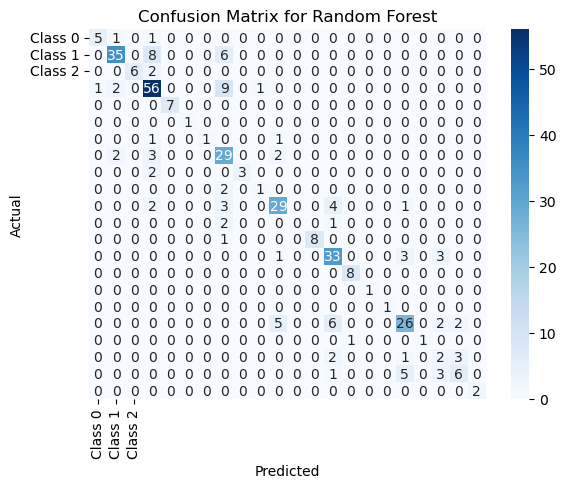

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


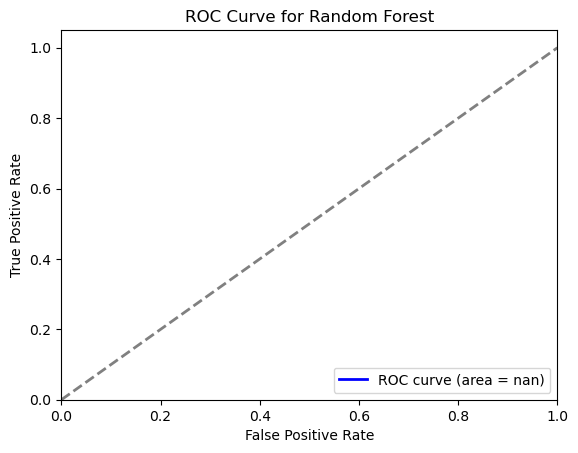


--------------------------------------------------


In [47]:
print_metrics("Random Forest", y_test, rf_pred)

Metrics for Logistic Regression:
Accuracy: 0.2017
Precision: 0.0481
Recall: 0.0838
F1-Score: 0.0560


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


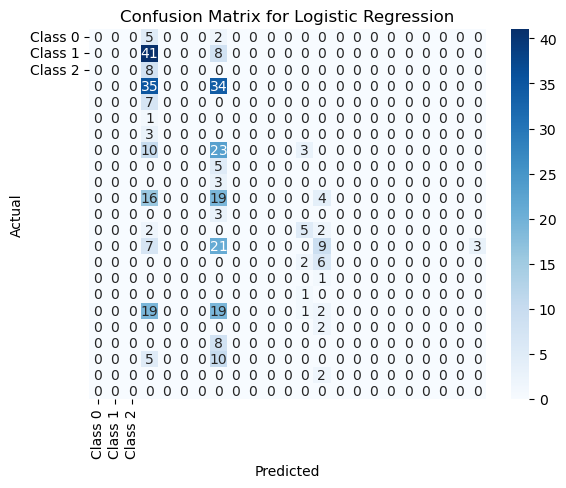

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


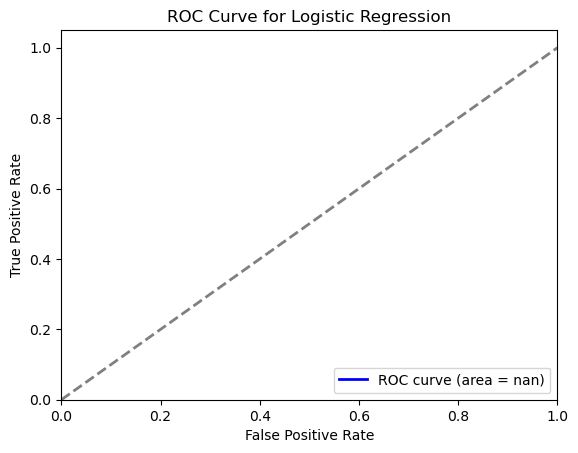


--------------------------------------------------


In [48]:
print_metrics("Logistic Regression", y_test, log_reg_pred)

Metrics for SVM:
Accuracy: 0.3613
Precision: 0.1159
Recall: 0.1356
F1-Score: 0.1148


C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


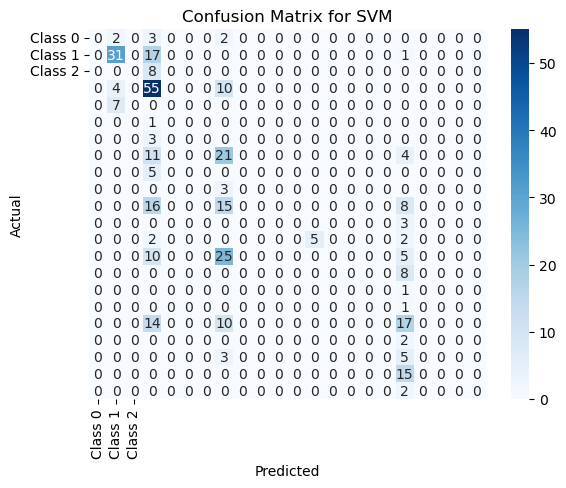

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1146: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


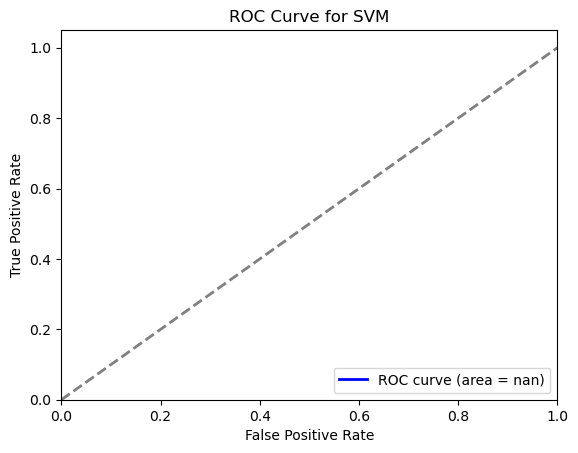


--------------------------------------------------


In [49]:
print_metrics("SVM", y_test, svm_pred)